In [ ]:
# ==========================================
#  DATA LOADING & MANIPULATION
# ==========================================
import pandas as pd
import numpy as np
# ==========================================
#  EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
# Optional: Make plots look a bit more modern/industrial out of the box
sns.set_theme(style="whitegrid")
#  OPTIONAL (To hide annoying warning messages)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. Extract the unique file ID from your original URL
file_id = "1QvbXM09YRMkD5N-lK4wtNNOdHG5cjbiX"

# 2. Create the direct download URL
url = f"https://drive.google.com/uc?id={file_id}"

dataset = pd.read_csv(url)
df = dataset.copy()


In [ ]:
print(df.head())
print("total row and column\n")
df.shape

                            Timestamp                 Email address  \
0  pd.options.display.max_rows = None   adityapatharkar16@gmail.com   
1                 24/02/2024 18:46:47  satyajitpatil.9031@gmail.com   
2                 26/02/2024 10:46:21      shivamrandive8@gmail.com   
3                 26/02/2024 11:09:09         spal5678910@gmail.com   
4                 26/02/2024 11:49:44       zaidiness2003@gmail.com   

  What type of area do you come from?  \
0                               Rural   
1                               Rural   
2                               Rural   
3                               Rural   
4                               Rural   

  How many earning people are in your family?  \
0                                    multiple   
1                                           1   
2                                           1   
3                                           1   
4                                    multiple   

  Did you or your family borrow

(330, 82)

In [ ]:
print("--- Missing Values (Columns with Missingness) ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts>0].sort_values(ascending=False))

--- Missing Values (Columns with Missingness) ---
Do you know about any places where you can get help for your mental health, like on campus or online?                                 16
 If yes, how much time do you dedicate to improving those skills or interests each week?                                              15
 How would you describe your parents' involvement in your academic life?                                                              12
How have you been feeling overall in the last week?                                                                                   12
Do you set specific goals related to your mental well-being?                                                                          12
 Do you have another plan if things don't work out the way you want in engineering?                                                   11
How do you think you'll handle it if it's tough to find a job in engineering after you finish college?                          

In [ ]:
print("\n--- Duplicated Rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


--- Duplicated Rows ---
Number of duplicate rows: 0


In [ ]:
# Inspect the distribution of our key target column (Stress)
target_col = " Have you experienced stress during your engineering studies?"
if target_col in df.columns:
    print(f"\n--- Target Column Distribution: '{target_col}' ---")
    print(df[target_col].value_counts(dropna=False))
else:
    # Just in case of leading/trailing space mismatches
    print("\nTarget column not found exactly; listing all columns containing 'stress':")
    print([c for c in df.columns if 'stress' in c.lower()])

    ''' By default, value_counts() hides missing/blank answers.
    Passing dropna=False forces Python to show us how many students left this question blank (NaN),
    which is crucial for data cleaning.'''


--- Target Column Distribution: ' Have you experienced stress during your engineering studies?' ---
 Have you experienced stress during your engineering studies?
Occasionally       163
Frequently         109
Rarely or never     53
NaN                  5
Name: count, dtype: int64


In [ ]:
#  Create a list of simple column names (q_0, q_1, q_2...) using a basic loop
new_columns=[]
for i in range(len(df.columns)):
  new_columns.append(f"q{i}")


In [ ]:
print(new_columns)

['q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q16', 'q17', 'q18', 'q19', 'q20', 'q21', 'q22', 'q23', 'q24', 'q25', 'q26', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36', 'q37', 'q38', 'q39', 'q40', 'q41', 'q42', 'q43', 'q44', 'q45', 'q46', 'q47', 'q48', 'q49', 'q50', 'q51', 'q52', 'q53', 'q54', 'q55', 'q56', 'q57', 'q58', 'q59', 'q60', 'q61', 'q62', 'q63', 'q64', 'q65', 'q66', 'q67', 'q68', 'q69', 'q70', 'q71', 'q72', 'q73', 'q74', 'q75', 'q76', 'q77', 'q78', 'q79', 'q80', 'q81']


In [ ]:
#  Change the names of the specific columns we care about
new_columns[0] = "timestamp"
new_columns[1] = "email"
new_columns[47] = "stress_level"

In [ ]:
df.columns=new_columns

In [ ]:
df.drop(columns=["timestamp", "email"],inplace=True)

In [ ]:
df["stress_level"].head(12)

,stress_level
0,Frequently
1,Frequently
2,Occasionally
3,Rarely or never
4,Rarely or never
5,Occasionally
6,Rarely or never
7,Frequently
8,Frequently
9,Occasionally


In [ ]:
for i in df.columns:
  if i != "stress_level":
    df[i] = df[i].fillna("Not Answered")


In [ ]:
# Remove the 5 rows where the student didn't answer the stress question
df = df.dropna(subset=["stress_level"])


In [ ]:
df.isnull().sum()


,0
q2,0
q3,0
q4,0
q5,0
q6,0
...,...
q77,0
q78,0
q79,0
q80,0


In [ ]:
# ==========================================
from sklearn.model_selection import train_test_split

# 1. Separate target (y) from features (X)
y = df["stress_level"]
X = df.drop(columns=["stress_level"])

In [ ]:
'''# 1. Print all columns in df that have missing values and how many they have
print("--- Columns in 'df' with NaN values ---")
null_columns = df.isnull().sum()
print(null_columns[null_columns > 0])

# 2. Show the exact rows in df that contain any NaN values
print("\n--- Rows with NaN values ---")
nan_rows = df[df.isnull().any(axis=1)]

if len(nan_rows) > 0:
    print(f"Total rows with NaNs: {len(nan_rows)}")
    for idx, row in nan_rows.iterrows():
        # Get the list of long column names that are missing in this row
        missing_cols = row[row.isnull()].index.tolist()
        print(f"\nRow Index {idx} is missing {len(missing_cols)} values:")
        for col in missing_cols:
            print(f"  - Column: \"{col}\"")
else:
    print("No rows contain NaN values in df!")'''


'# 1. Print all columns in df that have missing values and how many they have\nprint("--- Columns in \'df\' with NaN values ---")\nnull_columns = df.isnull().sum()\nprint(null_columns[null_columns > 0])\n\n# 2. Show the exact rows in df that contain any NaN values\nprint("\n--- Rows with NaN values ---")\nnan_rows = df[df.isnull().any(axis=1)]\n\nif len(nan_rows) > 0:\n    print(f"Total rows with NaNs: {len(nan_rows)}")\n    for idx, row in nan_rows.iterrows():\n        # Get the list of long column names that are missing in this row\n        missing_cols = row[row.isnull()].index.tolist()\n        print(f"\nRow Index {idx} is missing {len(missing_cols)} values:")\n        for col in missing_cols:\n            print(f"  - Column: "{col}"")\nelse:\n    print("No rows contain NaN values in df!")'

In [ ]:
#  2. Always Split data before doing anything which related to training and test after Data cleaning
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# 3. Print the size of the training and testing sets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (260, 79)
Testing set size: (65, 79)


In [ ]:
#  Define our custom order mapping for stress levels
target_map = {
    "Rarely or never": 0,
    "Occasionally": 1,
    "Frequently": 2
}

In [ ]:
# Map y_train and y_test separately
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

In [ ]:
# ==========================================
#  STEP 6: FEATURE CATEGORICAL ENCODING
# ==========================================
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
# 1. Automatically separate binary questions from multi-choice questions
binary_cols = []
multi_category_cols = []
for col in X_train.columns:
    unique_count = X_train[col].nunique()
    if unique_count <= 2:
        binary_cols.append(col)
    else:
        multi_category_cols.append(col)


In [ ]:
# 2. Define the Preprocessor
# - Binary columns (Yes/No) get encoded to 0 or 1
# - Multi-choice columns get converted to ordinal integers
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), binary_cols),
        ('multi', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), multi_category_cols)
    ]
)

In [ ]:
# 3. Fit on X_train and transform both training and testing features
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [ ]:
# 4. Convert the encoded results back to Pandas DataFrames
encoded_feature_names = preprocessor.get_feature_names_out()
X_train_clean = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

In [ ]:
# ==========================================
#  STEP 7: FEATURE SELECTION (SelectKBest)
# ==========================================
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# 1. We will select the top 15 most important features
k_features = 15

In [ ]:
# 2. Set up SelectKBest using Mutual Information Classifier
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)

In [ ]:
# 3. Fit the selector on our training data and transform both sets
# (This learns which columns are best from the training set only)
X_train_selected = selector.fit_transform(X_train_clean, y_train)
X_test_selected = selector.transform(X_test_clean)


In [ ]:

# 4. Get the names of the selected columns
selected_names = selector.get_feature_names_out()

In [ ]:
# 5. Convert back to DataFrames
X_train_final = pd.DataFrame(X_train_selected, columns=selected_names, index=X_train_clean.index)
X_test_final = pd.DataFrame(X_test_selected, columns=selected_names, index=X_test_clean.index)
print(f"Feature Selection Completed! Reduced features from {X_train_clean.shape[1]} to {X_train_final.shape[1]}")
print("\nThe selected top 15 columns are:")
print(list(X_train_final.columns))

Feature Selection Completed! Reduced features from 79 to 15

The selected top 15 columns are:
['binary__q10_Yes', 'binary__q21_Yes', 'multi__q4', 'multi__q7', 'multi__q17', 'multi__q28', 'multi__q32', 'multi__q38', 'multi__q40', 'multi__q48', 'multi__q53', 'multi__q57', 'multi__q60', 'multi__q61', 'multi__q73']


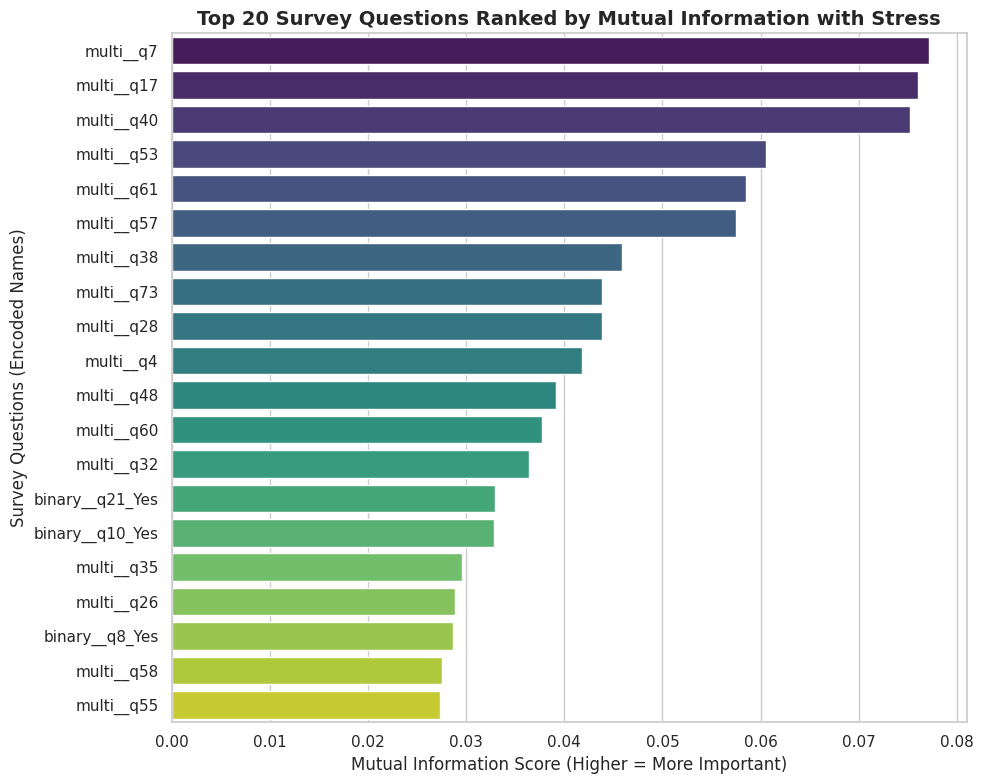

In [ ]:
# ==========================================
#  STEP 7.1: VISUALIZE FEATURE IMPORTANCES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the mutual information scores for ALL columns
mi_scores = pd.Series(selector.scores_, index=X_train_clean.columns)

# 2. Sort the scores in descending order and select the top 20 for comparison
mi_scores_sorted = mi_scores.sort_values(ascending=False).head(20)

# 3. Create a horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x=mi_scores_sorted.values,
    y=mi_scores_sorted.index,
    palette="viridis",
    hue=mi_scores_sorted.index,
    legend=False
)

# 4. Customize the plot look
plt.title("Top 20 Survey Questions Ranked by Mutual Information with Stress", fontsize=14, fontweight="bold")
plt.xlabel("Mutual Information Score (Higher = More Important)", fontsize=12)
plt.ylabel("Survey Questions (Encoded Names)", fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# ==========================================
#  STEP 8: BASELINE MODEL COMPARISON
# ==========================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np

In [ ]:
# 1. Initialize our three baseline models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}


In [ ]:
# 2. Define the cross-validation strategy (5-fold stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# 3. Evaluate each model and print the mean accuracy
print("--- 5-Fold Cross-Validation Scores (Accuracy) ---")
for name, model in models.items():
    # Run cross-validation on the training set
    scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring='accuracy')
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

--- 5-Fold Cross-Validation Scores (Accuracy) ---
Logistic Regression: 0.5154 (+/- 0.0445)
Random Forest: 0.4846 (+/- 0.0283)
Support Vector Machine: 0.5308 (+/- 0.0261)


Ensemble methods work best when they combine models that are already strong but make different kinds of mistakes. Once our baseline models are corrected and accurate, stacking them will combine their predictions to give us the final accuracy boost.

In [ ]:
# ==========================================
#  CORRECTED PIPELINE: MAPPING, NEW SPLIT, NEW SELECTION, & EVALUATION
# ==========================================
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd
import numpy as np

# 1. Create a clean copy of our dataframe
df_mapped = df.copy()

# 2. Define our logical mappings for Likert scales
frequency_map = {"Rarely or never": 0, "Occasionally": 1, "Frequently": 2, "Not Answered": -1}
time_map = {"Less than 6 hours": 0, "6-7 hours": 1, "7-8 hours": 2, "More than 8 hours": 3, "Not Answered": -1}
involvement_map = {"Not involved at all": 0, "Not very involved": 1, "Somewhat involved": 2, "Very involved": 3, "Not Answered": -1}
yes_no_map = {"No": 0, "Yes": 1, "Not Answered": -1}

# 3. Apply the mappings to the corresponding columns automatically
for col in df_mapped.columns:
    if col != "stress_level":
        unique_vals = set(df_mapped[col].dropna().unique())

        if unique_vals.issubset(set(frequency_map.keys())):
            df_mapped[col] = df_mapped[col].map(frequency_map)
        elif unique_vals.issubset(set(time_map.keys())):
            df_mapped[col] = df_mapped[col].map(time_map)
        elif unique_vals.issubset(set(involvement_map.keys())):
            df_mapped[col] = df_mapped[col].map(involvement_map)
        elif unique_vals.issubset(set(yes_no_map.keys())):
            df_mapped[col] = df_mapped[col].map(yes_no_map)

# 4. Safety net: Apply default Ordinal Encoding to any columns that couldn't be mapped
from sklearn.preprocessing import OrdinalEncoder
non_mapped_cols = [c for c in df_mapped.columns if df_mapped[c].dtype == 'object' and c != "stress_level"]
if len(non_mapped_cols) > 0:
    safety_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_mapped[non_mapped_cols] = safety_encoder.fit_transform(df_mapped[non_mapped_cols])

# 5. Separate features (X) and target (y)
X_m = df_mapped.drop(columns=["stress_level"])
y_m = df_mapped["stress_level"]

# 6. Re-run Train-Test Split (80% train, 20% test)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.20, random_state=42, stratify=y_m
)

# 7. Run Feature Selection fully on the new mapped data
selector_m = SelectKBest(score_func=mutual_info_classif, k=15)
X_train_final = selector_m.fit_transform(X_train_m, y_train_m)
X_test_final = selector_m.transform(X_test_m)

# Get names of the new top 15 features
selected_names = selector_m.get_feature_names_out()

# 8. Set up our baseline models
models_m = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

# 9. Evaluate the models using 5-Fold Cross-Validation
cv_m = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- New 5-Fold Cross-Validation Scores (Accuracy) ---")
for name, model in models_m.items():
    scores = cross_val_score(model, X_train_final, y_train_m, cv=cv_m, scoring='accuracy')
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

print("\nThe newly selected top 15 columns are:")
print(list(selected_names))


--- New 5-Fold Cross-Validation Scores (Accuracy) ---
Logistic Regression: 0.5654 (+/- 0.0821)
Random Forest: 0.4808 (+/- 0.1160)
Support Vector Machine: 0.5269 (+/- 0.0552)

The newly selected top 15 columns are:
['q5', 'q7', 'q8', 'q10', 'q22', 'q48', 'q51', 'q54', 'q55', 'q57', 'q60', 'q61', 'q67', 'q69', 'q80']


In [ ]:
# ==========================================
#  STEP 8.1: HYBRID ENCODING ON TOP 15 FEATURES
# ==========================================
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

# 1. Identify which of the top 15 columns are Nominal (unordered)
# q5 (payment), q48 (coping), q54 (different field) are nominal
nominal_features = ["q5", "q48", "q54"]

# The rest of the top 15 features are Ordinal (ordered scales or binary Yes/No)
ordinal_features = [col for col in selected_names if col not in nominal_features]

# 2. Extract these features from our split sets
X_train_top = X_train_m[selected_names]
X_test_top = X_test_m[selected_names]

# 3. Set up the hybrid preprocessor
hybrid_preprocessor = ColumnTransformer(
    transformers=[
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features)
    ]
)

# 4. Fit and transform the top features
X_train_final_hybrid = hybrid_preprocessor.fit_transform(X_train_top)
X_test_final_hybrid = hybrid_preprocessor.transform(X_test_top)

# 5. Re-run baseline evaluations on this hybrid data
print("--- Final Hybrid 5-Fold Cross-Validation Scores (Accuracy) ---")
for name, model in models_m.items():
    scores = cross_val_score(model, X_train_final_hybrid, y_train_m, cv=cv_m, scoring='accuracy')
    print(f"{name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


--- Final Hybrid 5-Fold Cross-Validation Scores (Accuracy) ---
Logistic Regression: 0.5846 (+/- 0.0756)
Random Forest: 0.4962 (+/- 0.0744)
Support Vector Machine: 0.5538 (+/- 0.0549)


In [ ]:
# ==========================================
#  STEP 9: FINAL STACKED ENSEMBLE TRAINING
# ==========================================
from sklearn.ensemble import StackingClassifier

# 1. Define the base estimators using our corrected settings
# (probability=True is required for SVM to be used in stacking)
base_estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

# 2. Define the meta-estimator
meta_estimator = LogisticRegression(random_state=42)

# 3. Create the Stacked Classifier
stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5  # Uses 5-fold cross-validation internally to train the meta-estimator
)

# 4. Evaluate the Stacked Ensemble using Cross-Validation
stacked_scores = cross_val_score(stacked_model, X_train_final_hybrid, y_train_m, cv=cv_m, scoring='accuracy')

print("--- Stacked Ensemble Performance ---")
print(f"Mean CV Accuracy: {np.mean(stacked_scores):.4f} (+/- {np.std(stacked_scores):.4f})")


--- Stacked Ensemble Performance ---
Mean CV Accuracy: 0.5269 (+/- 0.0432)


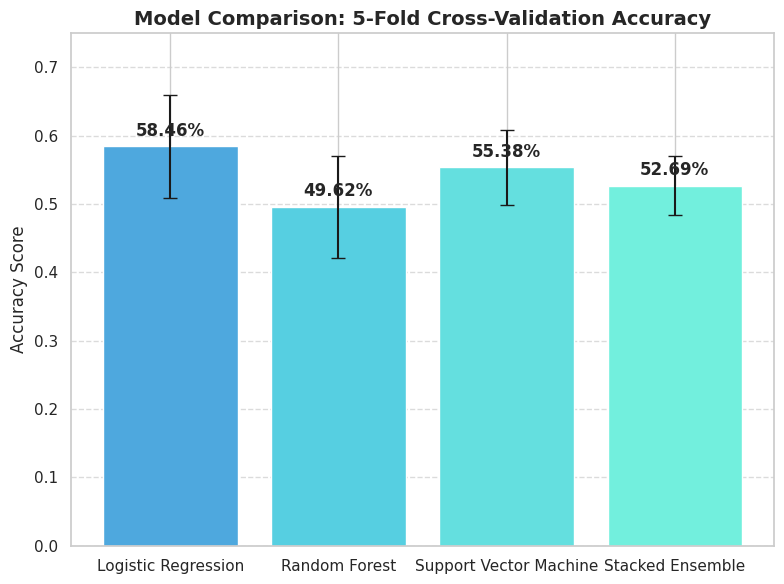

In [ ]:
# ==========================================
#  STEP 9.1: MODEL PERFORMANCE COMPARISON VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compile the average scores and standard deviations from our runs
model_names = ["Logistic Regression", "Random Forest", "Support Vector Machine", "Stacked Ensemble"]
mean_accuracies = [0.5846, 0.4962, 0.5538, 0.5269]
std_deviations = [0.0756, 0.0744, 0.0549, 0.0432]

# 2. Create the comparison bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, mean_accuracies, yerr=std_deviations, capsize=5, color=['#4ea8de', '#56cfe1', '#64dfdf', '#72efdd'])

# 3. Add labels and values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')

# 4. Customize plot details
plt.title("Model Comparison: 5-Fold Cross-Validation Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 0.75) # Set limit to easily see differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


=== Final Test Set Performance ===
Final Test Accuracy: 0.4923

Classification Report:
                 precision    recall  f1-score   support

Rarely or never       0.67      0.20      0.31        10
   Occasionally       0.53      0.58      0.55        33
     Frequently       0.42      0.50      0.46        22

       accuracy                           0.49        65
      macro avg       0.54      0.43      0.44        65
   weighted avg       0.51      0.49      0.48        65



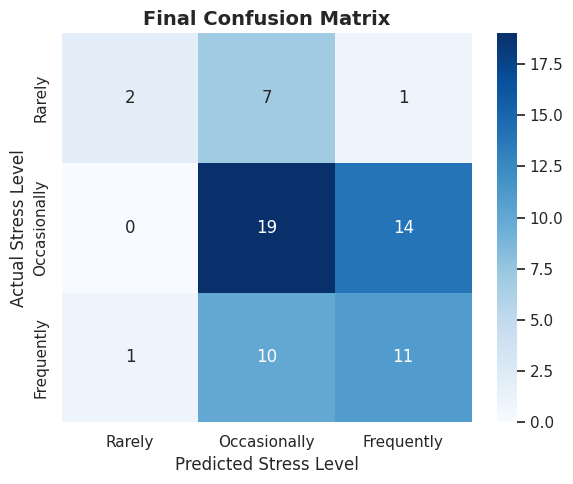

In [ ]:
# ==========================================
#  STEP 10: FINAL TEST SET EVALUATION
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Train the final Logistic Regression model on all training data
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_final_hybrid, y_train_m)

# 2. Make predictions on the locked Test Set
y_pred = final_model.predict(X_test_final_hybrid)

# 3. Print the final classification metrics
print("=== Final Test Set Performance ===")
print(f"Final Test Accuracy: {accuracy_score(y_test_m, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_m, y_pred, target_names=["Rarely or never", "Occasionally", "Frequently"]))

# 4. Plot the Confusion Matrix
conf_matrix = confusion_matrix(y_test_m, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rarely", "Occasionally", "Frequently"],
    yticklabels=["Rarely", "Occasionally", "Frequently"]
)
plt.title("Final Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Stress Level", fontsize=12)
plt.ylabel("Actual Stress Level", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
#  STEP 9.2: HYPERPARAMETER TUNING (GridSearchCV)
# ==========================================
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
# C is the inverse of regularization strength (smaller C = stronger regularization)
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2'],                  # Standard L2 regularization
    'solver': ['lbfgs', 'liblinear']    # Solvers compatible with L2
}

# 2. Set up the Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=cv_m,
    scoring='accuracy',
    n_jobs=-1
)

# 3. Fit the search on our training data
grid_search.fit(X_train_final_hybrid, y_train_m)

# 4. Print the best parameters and the new score
print("=== Grid Search Results ===")
print("Best Parameters:", grid_search.best_params_)
print(f"Best Tuned CV Accuracy: {grid_search.best_score_:.4f}")
print(f"Original Default CV Accuracy: 0.5846")


=== Grid Search Results ===
Best Parameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Tuned CV Accuracy: 0.5846
Original Default CV Accuracy: 0.5846


In [ ]:
# ==========================================
#  STEP 10: FINAL TEST EVALUATION & SAVE PIPELINE
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 1. Select the best tuned model from the Grid Search
best_tuned_model = grid_search.best_estimator_

# 2. Evaluate the tuned model on the locked Test Set
y_pred_tuned = best_tuned_model.predict(X_test_final_hybrid)

# 3. Print the final metrics
print("=== Final Tuned Test Set Performance ===")
print(f"Final Test Accuracy: {accuracy_score(y_test_m, y_pred_tuned):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_m, y_pred_tuned, target_names=["Rarely or never", "Occasionally", "Frequently"]))

# 4. Save the preprocessor, feature selector, and the model
joblib.dump(hybrid_preprocessor, 'hybrid_preprocessor.pkl')
joblib.dump(selector_m, 'feature_selector.pkl')
joblib.dump(best_tuned_model, 'tuned_stress_model.pkl')

print("\nPipeline components saved successfully!")
print("Saved files: 'hybrid_preprocessor.pkl', 'feature_selector.pkl', 'tuned_stress_model.pkl'")


=== Final Tuned Test Set Performance ===
Final Test Accuracy: 0.4923

Classification Report:
                 precision    recall  f1-score   support

Rarely or never       0.67      0.20      0.31        10
   Occasionally       0.53      0.58      0.55        33
     Frequently       0.42      0.50      0.46        22

       accuracy                           0.49        65
      macro avg       0.54      0.43      0.44        65
   weighted avg       0.51      0.49      0.48        65


Pipeline components saved successfully!
Saved files: 'hybrid_preprocessor.pkl', 'feature_selector.pkl', 'tuned_stress_model.pkl'
